# AU-AIR Object Detection

## Step 1: Environment Setup

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/uav-det/bin/python


In [2]:
import json
import os
import random
import shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Verify installs
import ultralytics
import sahi
print(f"ultralytics version : {ultralytics.__version__}")
print(f"sahi version        : {sahi.__version__}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ultralytics version : 8.4.37
sahi version        : 0.11.36


## Step 2: Dataset Exploration

In [3]:
DATA_DIR = Path("../data")
ANN_PATH = DATA_DIR / "annotations.json"
IMG_DIR  = DATA_DIR / "images"

with open(ANN_PATH) as f:
    raw = json.load(f)

CATEGORIES = raw["categories"]   # ['Human','Car','Truck','Van','Motorbike','Bicycle','Bus','Trailer']
annotations = raw["annotations"] # list of per-image dicts

print("Categories:", CATEGORIES)
print(f"Total images : {len(annotations):,}")
total_bboxes = sum(len(a["bbox"]) for a in annotations)
print(f"Total bboxes : {total_bboxes:,}")

Categories: ['Human', 'Car', 'Truck', 'Van', 'Motorbike', 'Bicycle', 'Bus', 'Trailer']
Total images : 32,823
Total bboxes : 132,031


### Class Distribution

In [4]:
class_counts = Counter()
for ann in annotations:
    for bbox in ann["bbox"]:
        class_counts[bbox["class"]] += 1

# Print sorted table
print(f"{'Class':<12} {'Count':>8} {'Percent':>8}")
print("-" * 32)
for cls_id, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    pct = 100 * count / total_bboxes
    print(f"{CATEGORIES[cls_id]:<12} {count:>8,} {pct:>7.2f}%")

Class           Count  Percent
--------------------------------
Car           102,619   77.72%
Van             9,995    7.57%
Truck           9,545    7.23%
Human           5,158    3.91%
Trailer         2,538    1.92%
Bicycle         1,128    0.85%
Bus               729    0.55%
Motorbike         319    0.24%


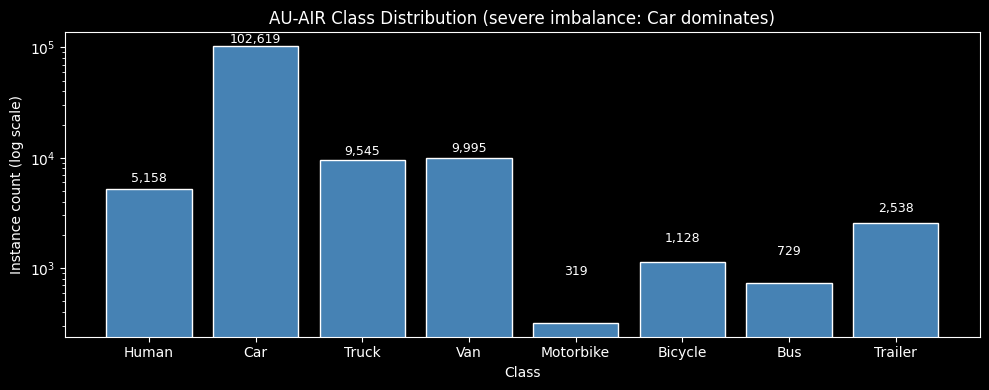

In [5]:
# Bar chart — class distribution
cls_ids   = sorted(class_counts.keys())
cls_names = [CATEGORIES[i] for i in cls_ids]
counts    = [class_counts[i] for i in cls_ids]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(cls_names, counts, color="steelblue", edgecolor="white")

# Annotate bars
for bar, cnt in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f"{cnt:,}",
        ha="center", va="bottom", fontsize=9
    )

ax.set_yscale("log")
ax.set_ylabel("Instance count (log scale)")
ax.set_title("AU-AIR Class Distribution (severe imbalance: Car dominates)")
ax.set_xlabel("Class")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

As we can see above, classes are not equally distributed, but it is normal when we deal with object detection tasks, especially from fisheye, UAV based scene images. Because vehicles kije motorbike, bus, bicycle are really few againts to the car, trucks etc.